# MID evaluation — Best-of-20 ADE/FDE

Load a trained checkpoint and report Best-of-20 ADE/FDE on the test (or val) split of a single scene.

**Pipeline:**
1. Rebuild the model architecture (encoder + diffusion) — same as training.
2. Load weights from the checkpoint saved by `train.ipynb`.
3. Build an eval DataLoader on `<scene>_test.pkl` with `min_history_length=7` (full 8-step history, paper convention) and no augmentation.
4. For each batch: sample 20 trajectories, integrate velocities to positions, compute ADE/FDE, take the min across the 20 samples.
5. Aggregate (mean) across all pedestrians.

## 1. Configuration

Point `CHECKPOINT` at whatever you saved from `train.ipynb`. The eval reconstructs the model with the hyperparams stored inside the checkpoint, so you only need to specify the scene + split here.

In [1]:
SCENE = "eth"            # which scene's test/val split to evaluate
SPLIT = "test"           # "test" or "val"
CHECKPOINT = f"../checkpoints/mid_{SCENE}.pt"

BATCH_SIZE = 256
NUM_SAMPLES = 20         # K in Best-of-K (paper uses 20)
SAMPLING = "ddpm"        # "ddpm" or "ddim"
STEP = 1                 # reverse-process stride. 1 = full diffusion chain.

# Paper convention: only evaluate pedestrians with the full 8-step history
# (current + 7 past). Setting this to 1 matches training's looser filter.
MIN_HISTORY = 7

# The ETH test set was scaled by 0.6 during preprocessing (a known quirk of
# the ETH/UCY benchmark). The literature reports numbers in the unscaled frame,
# so we divide ADE/FDE by 0.6 to match.
ETH_RESCALE = (SCENE == "eth" and SPLIT == "test")

SEED = 123

## 2. Setup: paths, device, seeds

In [2]:
import os
import sys
import random
import numpy as np
import torch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: mps


## 3. Load the checkpoint

The training notebook saves a dict with the architecture hyperparams + the two state dicts (registrar and diffusion). We rebuild the model fresh and load these in.

In [3]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
print(f"Loaded checkpoint: {CHECKPOINT}")
print(f"  trained on scene: {ckpt['scene']}")
print(f"  epochs:           {ckpt['epoch']}")
print(f"  encoder_dim:      {ckpt['encoder_dim']}")
print(f"  diffusion steps:  {ckpt['num_diffusion_steps']}")
if 'history' in ckpt and len(ckpt['history']):
    print(f"  final train loss: {ckpt['history'][-1]:.4f}")

Loaded checkpoint: ../checkpoints/mid_eth.pt
  trained on scene: eth
  epochs:           90
  encoder_dim:      256
  diffusion steps:  100
  final train loss: 0.0999


## 4. Load eval Environment + build DataLoader

Eval uses `shuffle=False, augment=False` and stricter `min_history=7`.

In [4]:
from mid_model import load_environment, build_dataloader, get_hyperparameters

pkl_path = os.path.join(PROJECT_ROOT, "processed_data", f"{SCENE}_{SPLIT}.pkl")
env = load_environment(pkl_path)
print(f"Loaded {pkl_path}")
print(f"  scenes: {len(env.scenes)}")
print(f"  total nodes: {sum(len(s.nodes) for s in env.scenes)}")

# Reuse the checkpoint's hyperparams so eval matches training exactly,
# but override the history filter to the paper convention (8-step history).
hyperparams = ckpt.get("hyperparams") or get_hyperparameters(encoder_dim=ckpt["encoder_dim"])
hyperparams = dict(hyperparams)
hyperparams["minimum_history_length"] = MIN_HISTORY

eval_loader, node_type = build_dataloader(
    env=env,
    hyperparams=hyperparams,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    augment=False,
)
print(f"\nNode type: {node_type}")
print(f"Batches: {len(eval_loader)}")

/opt/anaconda3/envs/ml_hw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded /Users/dhawaldixit/projects/ddpm/processed_data/eth_test.pkl
  scenes: 1
  total nodes: 360

Node type: PEDESTRIAN
Batches: 2


## 5. Rebuild model + load weights

Construct the same encoder + AutoEncoder as in training, then load the saved state dicts. The encoder's sub-models are registered inside the `ModelRegistrar` via `set_environment(env)`; that registration must happen BEFORE we load weights, so the keys line up.

In [5]:
from utils.model_registrar import ModelRegistrar
from models.trajectron import Trajectron
from mid_model import AutoEncoder

registrar = ModelRegistrar(model_dir=os.path.dirname(CHECKPOINT), device=DEVICE)
encoder = Trajectron(registrar, hyperparams, DEVICE)
encoder.set_environment(env)
encoder.set_annealing_params()

model = AutoEncoder(
    encoder=encoder,
    registrar=registrar,
    encoder_dim=ckpt["encoder_dim"],
    num_diffusion_steps=ckpt["num_diffusion_steps"],
    beta_1=1e-4,
    beta_T=5e-2,
    tf_layer=ckpt["tf_layer"],
).to(DEVICE)

registrar.model_dict.load_state_dict(ckpt["registrar_state_dict"])
model.diffusion.load_state_dict(ckpt["diffusion_state_dict"])
print("Weights loaded.")

Weights loaded.


/Users/dhawaldixit/projects/ddpm/mid_model/diffusion.py:168: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=tf_layer)


## 6. Run evaluation

Each batch: encode → run reverse diffusion 20 times → integrate velocities to positions → compute per-sample ADE/FDE → keep the min across the 20 samples per pedestrian. Mean across all pedestrians at the end.

In [6]:
from mid_model import evaluate

results = evaluate(
    model=model,
    dataloader=eval_loader,
    node_type=node_type,
    device=DEVICE,
    sample=NUM_SAMPLES,
    sampling=SAMPLING,
    step=STEP,
    eth_rescale=ETH_RESCALE,
)

print(f"\n══════════════════════════════════════════════")
print(f"  Scene:           {SCENE} / {SPLIT}")
print(f"  Pedestrians:     {results['n_pedestrians']}")
print(f"  Best-of-{NUM_SAMPLES} ADE: {results['ade']:.4f}")
print(f"  Best-of-{NUM_SAMPLES} FDE: {results['fde']:.4f}")
if ETH_RESCALE:
    print(f"  (ADE/FDE rescaled by 1/0.6 for the ETH benchmark frame)")
print(f"══════════════════════════════════════════════")

evaluating:   0%|                                                             | 0/2 [00:00<?, ?it/s]

evaluating: 100%|█████████████████████████████████████████████████████| 2/2 [01:39<00:00, 49.65s/it]


══════════════════════════════════════════════
  Scene:           eth / test
  Pedestrians:     364
  Best-of-20 ADE: 0.4654
  Best-of-20 FDE: 0.8668
  (ADE/FDE rescaled by 1/0.6 for the ETH benchmark frame)
══════════════════════════════════════════════


## 7. Per-pedestrian error distribution (optional)

Quick sanity check: how does the error vary across pedestrians? A long tail of high-error pedestrians usually means the model has trouble with rare motion patterns (sharp turns, stops).

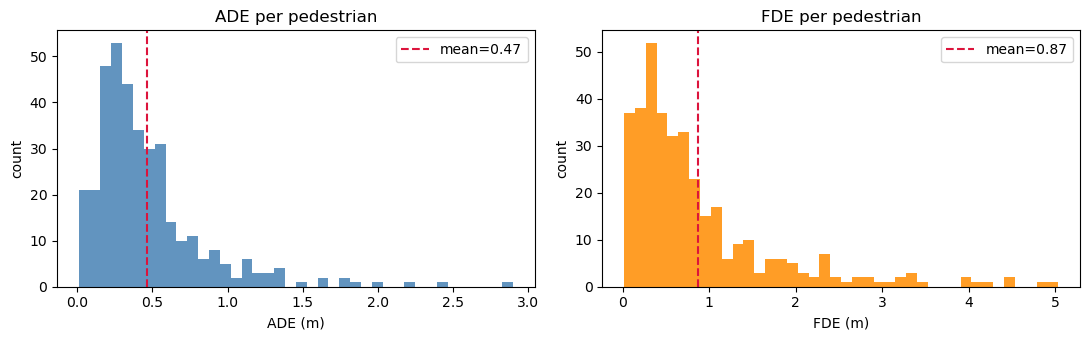

In [7]:
import matplotlib.pyplot as plt

ade_arr = results["ade_per_pedestrian"]
fde_arr = results["fde_per_pedestrian"]
if ETH_RESCALE:
    ade_arr = ade_arr / 0.6
    fde_arr = fde_arr / 0.6

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(ade_arr, bins=40, color="steelblue", alpha=0.85)
axes[0].axvline(ade_arr.mean(), color="crimson", linestyle="--", label=f"mean={ade_arr.mean():.2f}")
axes[0].set_title("ADE per pedestrian")
axes[0].set_xlabel("ADE (m)"); axes[0].set_ylabel("count"); axes[0].legend()

axes[1].hist(fde_arr, bins=40, color="darkorange", alpha=0.85)
axes[1].axvline(fde_arr.mean(), color="crimson", linestyle="--", label=f"mean={fde_arr.mean():.2f}")
axes[1].set_title("FDE per pedestrian")
axes[1].set_xlabel("FDE (m)"); axes[1].set_ylabel("count"); axes[1].legend()

plt.tight_layout()
plt.show()

## Reference numbers (paper, Best-of-20)

| Scene  | ADE  | FDE  |
|--------|------|------|
| eth    | 0.39 | 0.66 |
| hotel  | 0.13 | 0.22 |
| univ   | 0.22 | 0.45 |
| zara1  | 0.17 | 0.30 |
| zara2  | 0.13 | 0.27 |

With only 5 epochs of training (the notebook's smoke-test setting) you should be **well above** these numbers — they reflect 90 epochs of training with augmentation enabled. Use this notebook to check that ADE/FDE are *decreasing* across longer training runs, not to expect paper parity from a smoke test.